In value iteration and policy iteration, we had the complete knowledge of the transition probablitites and the reward schemes. If however, we did not have access to such privileged information, we rely on monte carlo methods to estimate these quantities. There are two ways we can do this, either estimate the transitions and rewards explicitly and then perform value or policy iterations (model-based) or estimate the state values or state-action values directly (model-free).

In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from gymnasium.wrappers import RecordVideo

In [2]:
NUM_EPISODES = 100000
EPSILON = np.linspace(0.9, 0.1, NUM_EPISODES)
DISCOUNT = 0.9
ALPHA = 0.1

In [ ]:
def train(env):
    obs_dim = env.observation_space.n
    act_dim = env.action_space.n

    Q = np.zeros((obs_dim, act_dim))
    reward_history = []

    for i, eps in enumerate(EPSILON):
        done = False
        total_reward = 0
        trajectory = []

        state, info = env.reset()
        while not done:
            action = np.argmax(Q[state]) if np.random.rand() > eps else env.action_space.sample()
            new_state, reward, terminated, truncated, info = env.step(action)

            trajectory.append([state, action, reward])
            total_reward += reward
            state = new_state
            done = terminated or truncated

        trajectory = np.array(trajectory)
        reversed_rewards = trajectory[::-1, 2]
        powers = np.arange(len(reversed_rewards))
        discounts = DISCOUNT ** powers

        discounted_rewards = np.cumsum(reversed_rewards * discounts)[::-1]
        reward_history.append(total_reward)
        
        for (s, a), G in zip(trajectory[:,:2], discounted_rewards):
            Q[s, a] += ALPHA * (G - Q[s, a])

        # if not (i+1) % 1000:
        #     print(f"Episode: {i+1}/{NUM_EPISODES}, Total reward: {total_reward}")

    return Q, reward_history

# Stochastic Environment

In [ ]:
env = gym.make("CliffWalking-v1", is_slippery=True)
Q, reward_history = train(env)

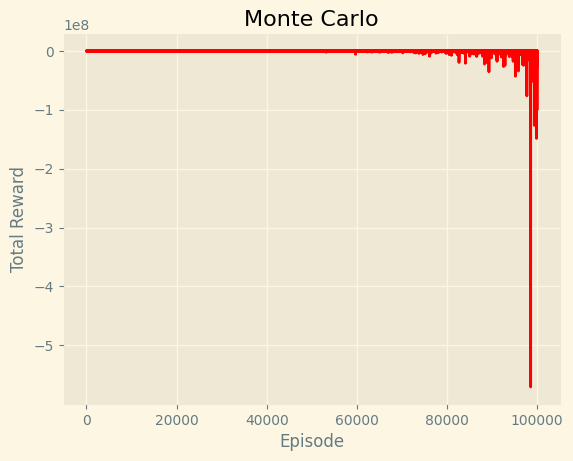

In [14]:
plt.style.use("Solarize_Light2")
plt.plot(reward_history, color="red")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Monte Carlo")
plt.show()

In [12]:
np.save('../experiments/mc_stochastic_rh.npy', reward_history)
np.save('../experiments/mc_stochastic_ag.npy', Q)

# Deterministic Environment

In [ ]:
env = gym.make("CliffWalking-v1", is_slippery=False)
Q, reward_history = train(env)

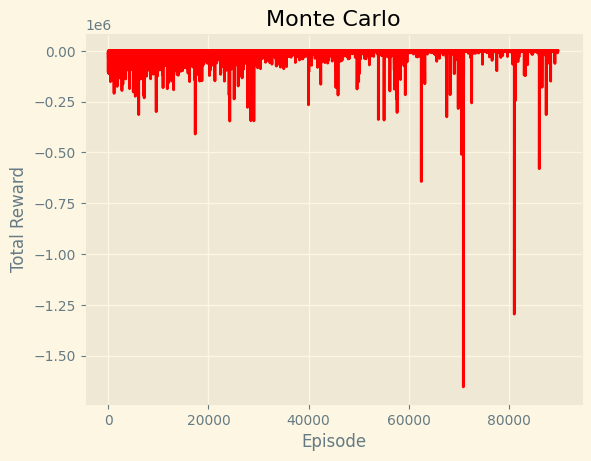

In [8]:
plt.style.use("Solarize_Light2")
plt.plot(reward_history[:90000], color="red")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Monte Carlo")
plt.show()

In [6]:
np.save('../experiments/mc_deterministic_rh.npy', reward_history)
np.save('../experiments/mc_deterministic_ag.npy', Q)

# Evalution

In [5]:
Q = np.load('../results/checkpoints/mc_stochastic_q.npy')

In [ ]:
eval_env = gym.make("CliffWalking-v1", is_slippery=True, render_mode="rgb_array")
eval_env = RecordVideo(eval_env, video_folder="../results/videos", name_prefix="mc_stochastic", episode_trigger=lambda x: True)

observation, info = eval_env.reset(seed=42)
terminated = False
while not terminated:
    action = np.argmax(Q[observation])
    observation, reward, terminated, truncated, info = eval_env.step(action)

    if truncated:
        observation, info = eval_env.reset()

eval_env.close()

Head over to `q_learning.ipynb` to see comparisons